<div style="text-align: center; line-height: 1.2;">
    <h1 style="margin-bottom: 10px;">GEARS Research Projects</h1>
    <h2 style="margin-top: 0;">Towards machine learning</h2>
</div>


### residuals = by least squares

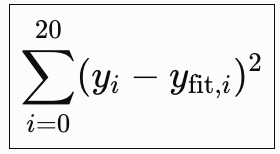


In [25]:
import numpy as np
import matplotlib.pyplot as plt



def polynomial_case(m, n, a):

#根据 m 生成 m + 1 个数据点
    t = np.linspace(0 , np.pi / 2 , m + 1)   # np.linspace(起点, 终点, 数量)

# 真实函数 y = sin(t)
    y = np.sin(a * t)

#根据 n 创建 Vandermonde matrix
# A 的形状为 (m + 1, n + 1)
    A = np.vander(              # Vandermonde matrix（范德蒙德矩阵）
    t,                          # 要处理的横坐标数据
    N = n + 1,                  # 生成多少列
    increasing=True             # 次数从低到高排列
)

# Step 3: 判断三种情况，并选择对应的解法
    if m > n:

        case_name = "m > n"
        system_name = "Over-determined system"
        problem_name = "Curve fitting"
        method_name = "Least squares"

        # 最小二乘解
        coefficients, residuals, rank, singular_values = np.linalg.lstsq(          #找到一个系数向量，使 Ac 尽可能接近 y。
            A,                   #是左边的矩阵。
            y,                   #希望拟合的目标值
            rcond=None           #rcond用来判断某些非常小的数是否应该被当成零，以避免计算不稳定。  #None = 使用 NumPy 推荐的默认判断标准。
        )

    elif m == n:

        case_name = "m = n"
        system_name = "Square system"         #方阵系统，矩阵行数等于列数
        problem_name = "Interpolation"        #精确通过所有给定数据点
        method_name = "Exact solution"        #Ax=y can be exact

        # 解方阵系统 Ax = y
        coefficients = np.linalg.solve(       # A是可逆方阵时，它会返回唯一解  x=A^(-1)y  #np.linalg.solve() 只返回方程的解
            A,
            y
        )

        # 单独计算其他信息
        rank = np.linalg.matrix_rank(A)       #rank

        singular_values = np.linalg.svd(      #计算奇异值  Singular Value Decomposition，奇异值分解
            A,
            compute_uv=False
        )

        # solve 不会返回 residuals
        residuals = np.array([])              #插值情况下理论残差应当接近零

    else:

        case_name = "m < n"
        system_name = "Under-determined system"       #欠定系统 方程数量少于未知数数量
        problem_name = "Multiple solutions"           #多个解
        method_name = "SVD minimum-norm solution"     #系数向量长度最小的解

        # 使用伪逆取得最小范数解
        coefficients = np.linalg.pinv(A) @ y          #pinv:伪逆 A^- -> A^+   x = A^+ * y

        # 单独计算其他信息
        rank = np.linalg.matrix_rank(A)       #计算秩

        singular_values = np.linalg.svd(      #计算奇异值
            A,
            compute_uv=False
        )

        # pinv 不会返回 residuals
        residuals = np.array([])

 # Step 4: 计算多项式在原始数据点上的结果

    y_fit = A @ coefficients    #y=Ax

# Step 5: 打印结果
    
    print("=" * 60)
    print("Case =", case_name)
    print("m =", m)
    print("n =", n)
    print("Number of data points =", m + 1)
    print("Number of unknown coefficients =", n + 1)
    print("A.shape =", A.shape)
    print("System type =", system_name)
    print("Problem type =", problem_name)
    print("Method =", method_name)
    print("Coefficients =", coefficients)
    print("Rank =", rank)
    print("Singular values =", singular_values)
    print("Residuals =", residuals)

    # --------------------------------------------------
    # Step 6: 把结果送出函数
    # --------------------------------------------------
    return t, y, A, coefficients, y_fit
#m>n
t1, y1, A1, coefficients1, y_fit1 = polynomial_case(
    m=20,
    n=2,
    a=3
)#m=n
t2, y2, A2, coefficients2, y_fit2 = polynomial_case(
    m=20,
    n=20,
    a=3
)
#m<n
t3, y3, A3, coefficients3, y_fit3 = polynomial_case(
    m=10,
    n=30,
    a=3
)

Case = m > n
m = 20
n = 2
Number of data points = 21
Number of unknown coefficients = 3
A.shape = (21, 3)
System type = Over-determined system
Problem type = Curve fitting
Method = Least squares
Coefficients = [ 0.23843373  2.08592209 -2.01577594]
Rank = 3
Singular values = [7.72102486 2.52243259 0.4737733 ]
Residuals = [0.82633814]
Case = m = n
m = 20
n = 20
Number of data points = 21
Number of unknown coefficients = 21
A.shape = (21, 21)
System type = Square system
Problem type = Interpolation
Method = Exact solution
Coefficients = [ 0.00000000e+00  3.00000000e+00  2.36371926e-08 -4.50000046e+00
  5.15794167e-06  2.02496120e+00  2.07703065e-04 -4.34754342e-01
  2.50683031e-03  4.83211158e-02  1.10071754e-02 -2.06633857e-02
  1.90075466e-02 -1.74035290e-02  1.29225199e-02 -7.36223549e-03
  3.18161541e-03 -1.01117895e-03  2.22620269e-04 -3.02951860e-05
  1.91863045e-06]
Rank = 19
Singular values = [1.16697391e+04 3.03112385e+02 2.25467649e+01 5.33881300e+00
 2.69381652e+00 1.03533696e+

In [50]:
def plot_polynomial_case(m, n, a):

    # 调用前面的计算函数
    t, y, A, coefficients, y_fit = polynomial_case(
        m,
        n,
        a
    )

    # 创建更密集的横坐标，用于绘制平滑曲线
    t_plot = np.linspace(
        0,
        np.pi / 2,
        300
    )

    # 根据当前 n 创建新的 Vandermonde 矩阵
    A_plot = np.vander(
        t_plot,
        N=n + 1,
        increasing=True
    )

    # 计算多项式在密集横坐标上的值
    y_plot = A_plot @ coefficients

    # 自动判断标题
    if m > n:
        case_name = "m > n: Over-determined"

    elif m == n:
        case_name = "m = n: Interpolation"

    else:
        case_name = "m < n: Under-determined"

    plt.figure(figsize=(8, 5))

    # 原始数据点
    plt.scatter(
        t,
        y,
        label="Sample data"
    )

    # 真实函数
    plt.plot(
        t_plot,
        np.sin(a * t_plot),
        label=f"True function: sin({a}t)"
    )

    # 参数化的多项式
    plt.plot(
        t_plot,
        y_plot,
        color="gold",
        label=f"Polynomial degree n={n}"
    )

    plt.xlabel("t")
    plt.ylabel("y")

    plt.title(
        f"{case_name}, m={m}, n={n}, a={a}"
    )

    plt.legend()
    plt.grid()
    plt.ylim(-7, 7)
    plt.show()



Case = m > n
m = 20
n = 2
Number of data points = 21
Number of unknown coefficients = 3
A.shape = (21, 3)
System type = Over-determined system
Problem type = Curve fitting
Method = Least squares
Coefficients = [ 0.23843373  2.08592209 -2.01577594]
Rank = 3
Singular values = [7.72102486 2.52243259 0.4737733 ]
Residuals = [0.82633814]


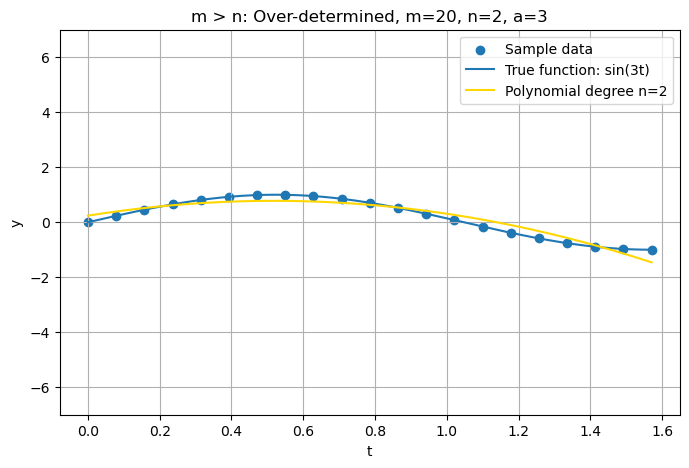

Case = m = n
m = 20
n = 20
Number of data points = 21
Number of unknown coefficients = 21
A.shape = (21, 21)
System type = Square system
Problem type = Interpolation
Method = Exact solution
Coefficients = [ 0.00000000e+00  4.66569328e+05 -2.09983570e+07  4.11980403e+08
 -4.75088060e+09  3.64598570e+10 -1.99291871e+11  8.09157659e+11
 -2.50849139e+12  6.04804159e+12 -1.14764696e+13  1.72562615e+13
 -2.06082475e+13  1.95069657e+13 -1.45334570e+13  8.41214683e+12
 -3.70190341e+12  1.19592267e+12 -2.67259334e+11  3.68928389e+10
 -2.36901970e+09]
Rank = 19
Singular values = [1.16697391e+04 3.03112385e+02 2.25467649e+01 5.33881300e+00
 2.69381652e+00 1.03533696e+00 3.53955210e-01 1.09101697e-01
 3.05495376e-02 7.77945398e-03 1.79597492e-03 3.73351261e-04
 6.91464069e-05 1.12362460e-05 1.56869796e-06 1.82890408e-07
 1.71400800e-08 1.22571840e-09 6.20131691e-11 1.95425125e-12
 2.69113766e-14]
Residuals = []


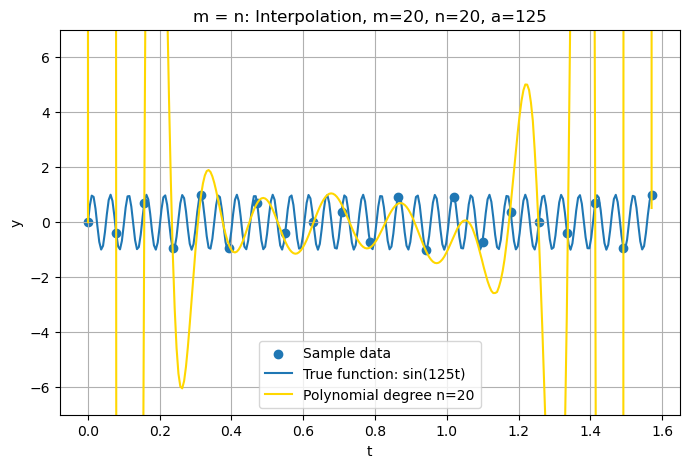

In [58]:
plot_polynomial_case(
    m=20,
    n=2,
    a=3
)

plot_polynomial_case(
    m=20,
    n=20,
    a=125
)


Case = m < n
m = 10
n = 30
Number of data points = 11
Number of unknown coefficients = 31
A.shape = (11, 31)
System type = Under-determined system
Problem type = Multiple solutions
Method = SVD minimum-norm solution
Coefficients = [ 2.61506163e-10  3.01378005e+00 -1.72732594e-01 -3.83642395e+00
 -6.80587977e-01  1.19719094e+00  1.14897151e+00  3.91331236e-01
 -2.54475250e-01 -5.35200547e-01 -5.00158762e-01 -2.90489242e-01
 -3.70546693e-02  1.72496781e-01  2.94686284e-01  3.20258782e-01
  2.62785528e-01  1.49074856e-01  1.18861652e-02 -1.15576384e-01
 -2.04144666e-01 -2.32794717e-01 -1.92768191e-01 -9.16630170e-02
  4.32578807e-02  1.64507791e-01  2.10663001e-01  1.27294413e-01
 -8.32829911e-02 -2.58435276e-01  1.25411806e-01]
Rank = 11
Singular values = [9.92884102e+05 5.91734828e+03 1.02606386e+02 6.41310742e+00
 2.71835137e+00 1.10610900e+00 3.75764444e-01 1.09547956e-01
 2.71542571e-02 5.46341659e-03 7.79575351e-04]
Residuals = []


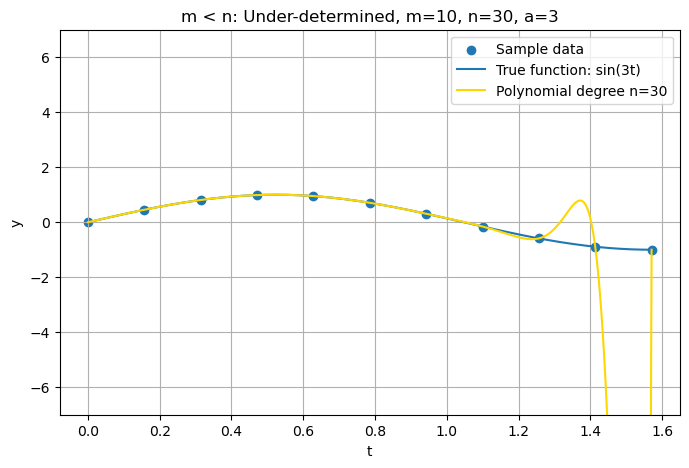

In [60]:
plot_polynomial_case(
    m=10,
    n=30,
    a=3
)

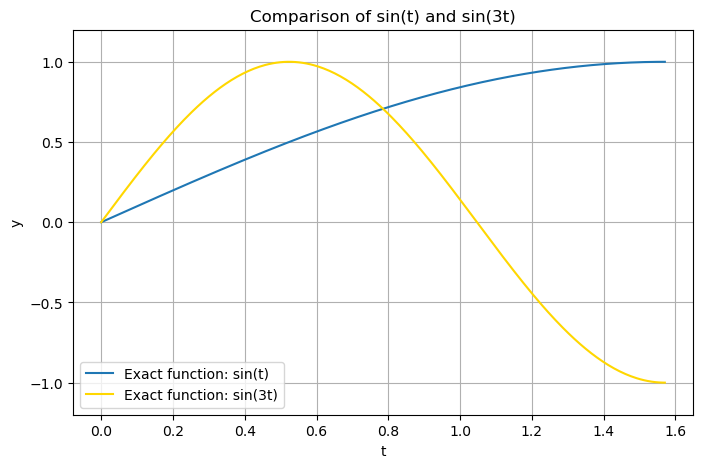

In [31]:
t_plot = np.linspace(
    0,
    np.pi / 2,
    300
)
y_sin_t = np.sin(t_plot)
y_sin_3t = np.sin(3 * t_plot)
plt.figure(figsize=(8, 5))
plt.plot(
    t_plot,
    y_sin_t,
    label="Exact function: sin(t)"
)
plt.plot(
    t_plot,
    y_sin_3t,
    color="gold",
    label="Exact function: sin(3t)"
)
plt.xlabel("t")
plt.ylabel("y")
plt.title("Comparison of sin(t) and sin(3t)")
plt.ylim(-1.2, 1.2)
plt.legend()
plt.grid()
plt.show()